# OpenDP Noise Runs

This notebook generates block-level OpenDP Laplace noise for several epsilon values, aggregates the adjusted counts to tract/county/state, and saves each run under `data/processed_data/DP_noise/epsilon_<value>/`.

The hierarchy is rebuilt from `data/il_pl2010_b/il_pl2010_b.csv` so the saved GEOIDs remain unique statewide during aggregation.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dp_noise_pipeline import (
    DEFAULT_EPSILONS,
    DEFAULT_OUTPUT_ROOT,
    epsilon_output_dir,
    format_epsilon,
    run_epsilons,
)


/Users/rf50/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
EPSILONS = DEFAULT_EPSILONS
OUTPUT_ROOT = DEFAULT_OUTPUT_ROOT

RERUN_GENERATION = False
summary_path = OUTPUT_ROOT / 'DP_noise_error_summary.csv'

if RERUN_GENERATION or not summary_path.exists():
    summary_df, _ = run_epsilons(EPSILONS, OUTPUT_ROOT)

summary_df = pd.read_csv(summary_path)
summary_df


,n,mean_error,mean_abs_error,median_abs_error,max_abs_error,rmse,epsilon,level
0,451554.0,1.635347e+01,1.914594e+01,15.0,196.0,2.552968e+01,0.1,block
1,451554.0,7.779998e+00,9.610211e+00,7.0,82.0,1.279040e+01,0.2,block
2,451554.0,2.925043e+00,3.874356e+00,3.0,41.0,5.153717e+00,0.5,block
3,451554.0,1.372365e+00,1.924100e+00,2.0,19.0,2.599599e+00,1.0,block
4,451554.0,5.978776e-01,9.086488e-01,1.0,9.0,1.317068e+00,2.0,block
5,102.0,7.239682e+04,7.239682e+04,44820.0,1371257.0,1.556990e+05,0.1,county
6,102.0,3.444205e+04,3.444205e+04,21620.5,641150.0,7.307105e+04,0.2,county
7,102.0,1.294917e+04,1.294917e+04,8465.5,228066.0,2.638516e+04,0.5,county
8,102.0,6.075461e+03,6.075461e+03,3969.5,105727.0,1.227267e+04,1.0,county
9,102.0,2.646804e+03,2.646804e+03,1742.5,45289.0,5.284195e+03,2.0,county


In [3]:
saved_paths = {
    format_epsilon(eps): epsilon_output_dir(OUTPUT_ROOT, eps)
    for eps in EPSILONS
}
saved_paths


{'0.1': PosixPath('data/processed_data/DP_noise/epsilon_0.1'),
 '0.2': PosixPath('data/processed_data/DP_noise/epsilon_0.2'),
 '0.5': PosixPath('data/processed_data/DP_noise/epsilon_0.5'),
 '1': PosixPath('data/processed_data/DP_noise/epsilon_1'),
 '2': PosixPath('data/processed_data/DP_noise/epsilon_2')}

/Users/rf50/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


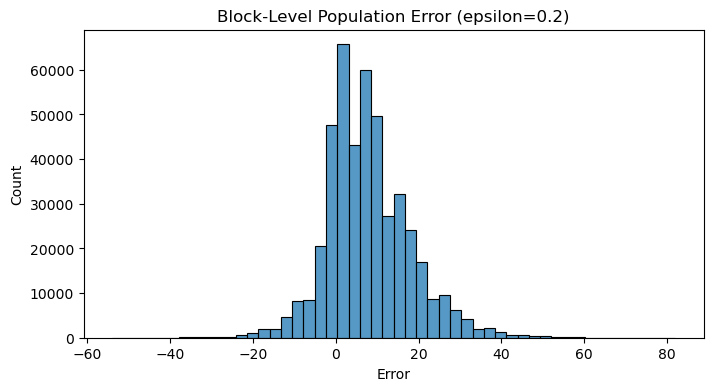

In [4]:
example_epsilon = EPSILONS[1] if len(EPSILONS) > 1 else EPSILONS[0]
example_block = pd.read_csv(
    epsilon_output_dir(OUTPUT_ROOT, example_epsilon) / 'DF_IL_2010_BLOCK_DP.csv'
).copy()
example_block['pop_error'] = example_block['adj_pop'] - example_block['true_pop']

plt.figure(figsize=(8, 4))
sns.histplot(example_block['pop_error'], bins=50)
plt.title(f'Block-Level Population Error (epsilon={example_epsilon:g})')
plt.xlabel('Error')
plt.ylabel('Count')
plt.show()


/Users/rf50/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rf50/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rf50/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/rf50/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length

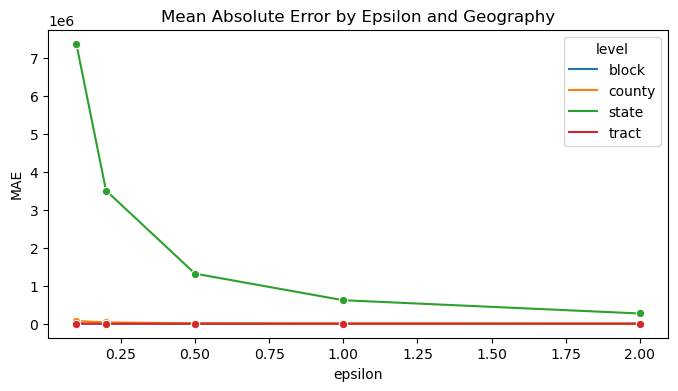

In [5]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=summary_df, x='epsilon', y='mean_abs_error', hue='level', marker='o')
plt.title('Mean Absolute Error by Epsilon and Geography')
plt.ylabel('MAE')
plt.show()


In [6]:
pd.read_csv(OUTPUT_ROOT / 'DP_noise_error_summary.csv')


,n,mean_error,mean_abs_error,median_abs_error,max_abs_error,rmse,epsilon,level
0,451554.0,1.635347e+01,1.914594e+01,15.0,196.0,2.552968e+01,0.1,block
1,451554.0,7.779998e+00,9.610211e+00,7.0,82.0,1.279040e+01,0.2,block
2,451554.0,2.925043e+00,3.874356e+00,3.0,41.0,5.153717e+00,0.5,block
3,451554.0,1.372365e+00,1.924100e+00,2.0,19.0,2.599599e+00,1.0,block
4,451554.0,5.978776e-01,9.086488e-01,1.0,9.0,1.317068e+00,2.0,block
5,102.0,7.239682e+04,7.239682e+04,44820.0,1371257.0,1.556990e+05,0.1,county
6,102.0,3.444205e+04,3.444205e+04,21620.5,641150.0,7.307105e+04,0.2,county
7,102.0,1.294917e+04,1.294917e+04,8465.5,228066.0,2.638516e+04,0.5,county
8,102.0,6.075461e+03,6.075461e+03,3969.5,105727.0,1.227267e+04,1.0,county
9,102.0,2.646804e+03,2.646804e+03,1742.5,45289.0,5.284195e+03,2.0,county
